# Asset Class Trend Following 策略回測 (2025成-1)

In [1]:
# --- 全域參數設定區塊 ---
SMA_PERIOD = 35
ROC_PERIOD = 56
STOP_LOSS_PCT = 0.09
INITIAL_CAPITAL = 30000000
DATA_FILE = '個股1.xlsx'


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [3]:
def clean_data(filepath):
    df_raw = pd.read_excel(filepath, header=None)
    stock_codes = df_raw.iloc[0, 2:].values
    stock_names = df_raw.iloc[1, 2:].values
    dates = pd.to_datetime(df_raw.iloc[2:, 1])
    prices = df_raw.iloc[2:, 2:].astype(float)
    prices.index = dates
    prices.columns = stock_codes
    code_to_name = dict(zip(stock_codes, stock_names))
    prices = prices.ffill().bfill()
    return prices, code_to_name


In [4]:
import pandas as pd
import numpy as np
import pickle

class Backtester:
    def __init__(self, prices, code_to_name, initial_capital=30000000):
        self.prices_df = prices
        self.prices = prices.values
        self.dates = prices.index
        self.assets = prices.columns
        self.code_to_name = code_to_name
        self.initial_capital = initial_capital
        
    def run(self, sma_period, roc_period, stop_loss_pct):
        # 2c. Indicators
        sma = self.prices_df.rolling(window=sma_period).mean().values
        # ROC: (P[t] - P[t-n]) / P[t-n]
        roc = self.prices_df.pct_change(periods=roc_period).values
        
        cash = self.initial_capital
        # portfolio: {asset_idx: {'shares': ..., 'max_price': ..., 'buy_price': ..., 'buy_date': ...}}
        portfolio = {} 
        equity_curve = np.zeros(len(self.dates))
        trades_log = []
        holdings_history = []
        
        start_idx = max(sma_period, roc_period)
        
        for i in range(start_idx, len(self.dates)):
            date = self.dates[i]
            current_prices = self.prices[i]
            
            # 1. Calculate current equity (at today's close)
            total_equity = cash
            for asset_idx, info in portfolio.items():
                total_equity += info['shares'] * current_prices[asset_idx]
            equity_curve[i] = total_equity
            
            if i == len(self.dates) - 1:
                break # End of data
            
            next_prices = self.prices[i+1]
            
            # 2. Check for daily Stop Loss (2b. Peak-to-Trough)
            # Signal today (T), execute tomorrow (T+1)
            triggered_sl_idxs = []
            for asset_idx, info in portfolio.items():
                curr_p = current_prices[asset_idx]
                if curr_p > info['max_price']:
                    info['max_price'] = curr_p
                
                if curr_p < info['max_price'] * (1 - stop_loss_pct):
                    triggered_sl_idxs.append(asset_idx)
            
            # 3. Check for Rebalancing (every 5 days)
            is_rebalance_day = (i - start_idx) % 5 == 0
            
            top_3_signals = []
            if is_rebalance_day:
                # 進場邏輯：價格高於 SMA，且 ROC 為正
                eligible_mask = (current_prices > sma[i]) & (roc[i] > 0)
                if np.any(eligible_mask):
                    eligible_idxs = np.where(eligible_mask)[0]
                    eligible_rocs = roc[i][eligible_idxs]
                    # 選取 ROC 前 3 名
                    num_to_pick = min(3, len(eligible_idxs))
                    top_idxs = eligible_idxs[np.argsort(eligible_rocs)[-num_to_pick:][::-1]]
                    top_3_signals = list(top_idxs)
            
            # 4. Execution Logic (T+1 at close)
            # Priority: Stop loss sell > Rebalance sell > Rebalance buy
            
            # Determine sells
            assets_to_sell = set(triggered_sl_idxs)
            if is_rebalance_day:
                for asset_idx in portfolio.keys():
                    if asset_idx not in top_3_signals:
                        assets_to_sell.add(asset_idx)
            
            # Execute sells at T+1 close
            for asset_idx in list(assets_to_sell):
                if asset_idx in portfolio:
                    info = portfolio.pop(asset_idx)
                    sell_price = next_prices[asset_idx]
                    # 賣出手續費 0.1425%, 賣出證交稅 0.3%
                    proceeds = info['shares'] * sell_price * (1 - 0.001425 - 0.003)
                    cash += proceeds
                    
                    reason = "停損" if asset_idx in triggered_sl_idxs else "再平衡"
                    trades_log.append({
                        '日期': date, # Signal date
                        '股票代號': self.assets[asset_idx],
                        '狀態': '賣出',
                        '價格': current_prices[asset_idx], # Signal price
                        '股數': 0,
                        '動能值': f"{roc[i][asset_idx]*100:.2f}%",
                        '標的名稱': self.code_to_name[self.assets[asset_idx]],
                        '原因': reason,
                        '說明': f"{reason}賣出：{self.code_to_name[self.assets[asset_idx]]}"
                    })

            # Execute buys at T+1 close
            if is_rebalance_day:
                # 僅賣出跌出排名的標的，並新增新的標的
                # 若原有持股仍位列前 3 名，則「保持原股數續抱」
                assets_to_buy = [a for a in top_3_signals if a not in portfolio]
                
                # Each slot gets 1/3 of INITIAL capital as per instructions (or threshold)
                # "平均分配至前 3 大持股"
                # Memory says 10,000,000 per slot.
                slot_cap = self.initial_capital / 3
                
                for asset_idx in assets_to_buy:
                    if len(portfolio) >= 3: break
                    
                    buy_price_exec = next_prices[asset_idx]
                    # 買進手續費 0.1425%
                    shares = int(slot_cap // (buy_price_exec * 1.001425))
                    cost = shares * buy_price_exec * 1.001425
                    
                    if shares > 0 and cash >= cost:
                        cash -= cost
                        portfolio[asset_idx] = {
                            'shares': shares,
                            'max_price': buy_price_exec,
                            'buy_price': buy_price_exec,
                            'buy_date': self.dates[i+1]
                        }
                        trades_log.append({
                            '日期': date,
                            '股票代號': self.assets[asset_idx],
                            '狀態': '買進',
                            '價格': current_prices[asset_idx],
                            '股數': shares,
                            '動能值': f"{roc[i][asset_idx]*100:.2f}%",
                            '標的名稱': self.code_to_name[self.assets[asset_idx]],
                            '原因': '符合趨勢',
                            '說明': f"買進新持有商品：{self.code_to_name[self.assets[asset_idx]]}"
                        })
                
                # Log Retain
                for asset_idx in portfolio.keys():
                    if asset_idx in top_3_signals and asset_idx not in assets_to_buy:
                        trades_log.append({
                            '日期': date,
                            '股票代號': self.assets[asset_idx],
                            '狀態': '保持',
                            '價格': current_prices[asset_idx],
                            '股數': portfolio[asset_idx]['shares'],
                            '動能值': f"{roc[i][asset_idx]*100:.2f}%",
                            '標的名稱': self.code_to_name[self.assets[asset_idx]],
                            '原因': '趨勢持續',
                            '說明': f"保留與上一期相同：{self.code_to_name[self.assets[asset_idx]]}"
                        })

            holdings_history.append({
                'Date': date,
                'Holdings': ", ".join([f"{self.code_to_name[self.assets[a]]}({self.assets[a]})" for a in portfolio.keys()]),
                'Count': len(portfolio),
                'Equity': total_equity
            })

        # Fill the last day's equity
        # For dates before start_idx, equity is initial_capital
        eq_series = pd.Series(equity_curve, index=self.dates)
        eq_series.iloc[:start_idx] = self.initial_capital
        # Replace 0 with NaN then ffill
        eq_series = eq_series.replace(0, np.nan).ffill()
        
        return eq_series, pd.DataFrame(trades_log), pd.DataFrame(holdings_history)

def calculate_metrics(equity_curve):
    if equity_curve.empty: return 0, 0, 0, 0
    total_return = (equity_curve.iloc[-1] / equity_curve.iloc[0]) - 1
    years = (equity_curve.index[-1] - equity_curve.index[0]).days / 365.25
    cagr = (1 + total_return) ** (1 / years) - 1 if years > 0 else 0
    
    rolling_max = equity_curve.cummax()
    drawdowns = (equity_curve - rolling_max) / rolling_max
    max_dd = drawdowns.min()
    calmar = cagr / abs(max_dd) if max_dd != 0 else 0
    
    return cagr, max_dd, calmar, total_return

def calculate_win_rate(trades_df):
    if trades_df.empty: return 0
    # Calculate daily win rate based on trades_df log.
    # A simpler but accurate way for this context:
    # A 'win' is when a '賣出' price is higher than the corresponding '買進' price.
    
    wins = 0
    total_round_trips = 0
    
    # We can track holdings by symbol
    holdings = {} # symbol -> buy_price
    
    # Sort trades by date
    trades_sorted = trades_df.sort_values('日期')
    
    for _, row in trades_sorted.iterrows():
        symbol = row['股票代號']
        status = row['狀態']
        price = row['價格']
        
        if status == '買進':
            holdings[symbol] = price
        elif status == '賣出':
            if symbol in holdings:
                buy_price = holdings.pop(symbol)
                total_round_trips += 1
                if price > buy_price:
                    wins += 1
                    
    return wins / total_round_trips if total_round_trips > 0 else 0



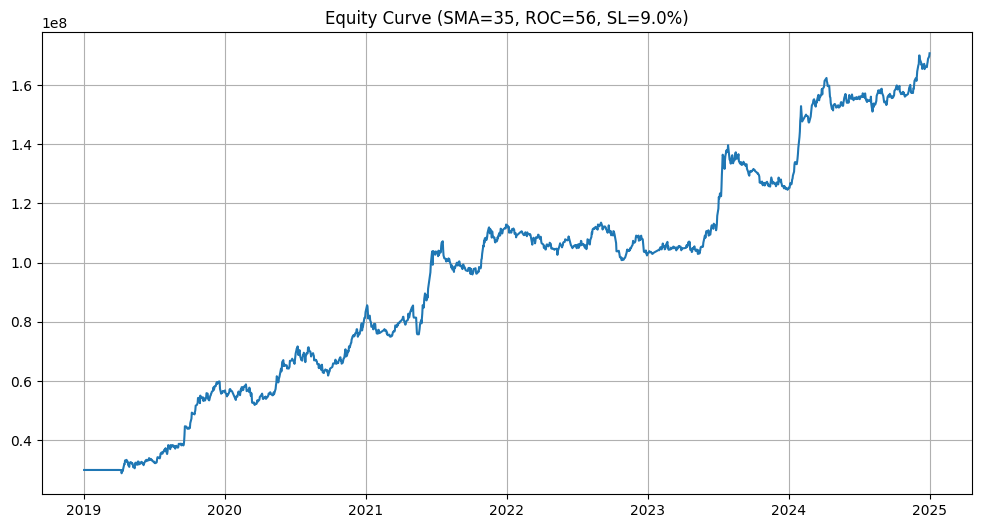

In [5]:
prices, code_to_name = clean_data(DATA_FILE)
bt = Backtester(prices, code_to_name, INITIAL_CAPITAL)
eq, trades, hold = bt.run(SMA_PERIOD, ROC_PERIOD, STOP_LOSS_PCT)

plt.figure(figsize=(12, 6))
plt.plot(eq)
plt.title('Equity Curve (SMA=35, ROC=56, SL=9.0%)')
plt.grid(True)
plt.show()
